In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
dados_path = Path("dados")

arquivos = [
    "todos_1cont_100users.csv",
    "todos_1cont_400users.csv",
    "todos_1cont_720users.csv",
    "todos_2cont_100users.csv",
    "todos_2cont_400users.csv",
    "todos_2cont_720users.csv",
    "todos_3cont_100users.csv",
    "todos_3cont_400users.csv",
    "todos_3cont_720users.csv",
]

In [8]:
registros = []

for arquivo in arquivos:
    df = pd.read_csv(dados_path / arquivo)
    agregado = df[df["Name"] == "Aggregated"].iloc[0]

    partes = arquivo.replace(".csv", "").split("_")
    containers = int(partes[1].replace("cont", ""))
    usuarios = int(partes[2].replace("users", ""))

    registros.append({
        "containers": containers,
        "usuarios": usuarios,
        "tempo_medio_resposta": agregado["Average Response Time"],
        "mediana_resposta": agregado["Median Response Time"],
        "rps": agregado["Requests/s"],
        "falhas": agregado["Failure Count"],
        "requisicoes": agregado["Request Count"]
    })

resultado = pd.DataFrame(registros)
resultado

,containers,usuarios,tempo_medio_resposta,mediana_resposta,rps,falhas,requisicoes
0,1,100,85.038751,73.0,46.337761,0,4385
1,1,400,238.399372,140.0,175.919554,0,13690
2,1,720,658.078415,530.0,262.554724,681,26000
3,2,100,93.528778,78.0,45.917771,0,4058
4,2,400,258.423222,120.0,174.418391,0,11431
5,2,720,600.852828,400.0,272.332798,5085,55178
6,3,100,106.972071,85.0,45.148708,0,3994
7,3,400,303.841177,130.0,171.159725,0,19591
8,3,720,523.117581,210.0,279.067485,10818,38948


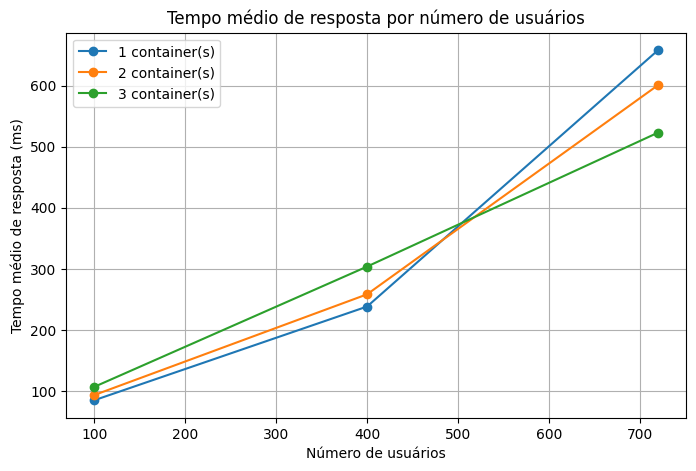

In [9]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["tempo_medio_resposta"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio de resposta por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

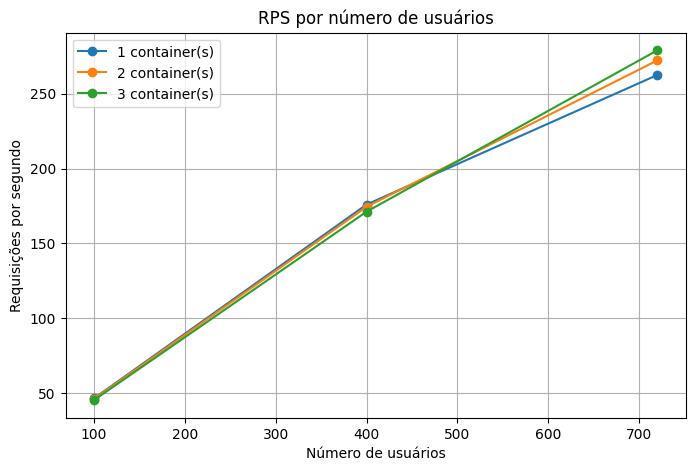

In [10]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["rps"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Requisições por segundo")
plt.title("RPS por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

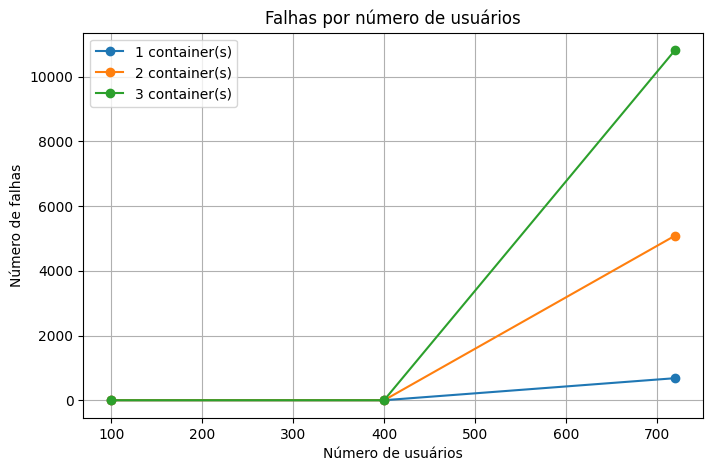

In [11]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["falhas"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Número de falhas")
plt.title("Falhas por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

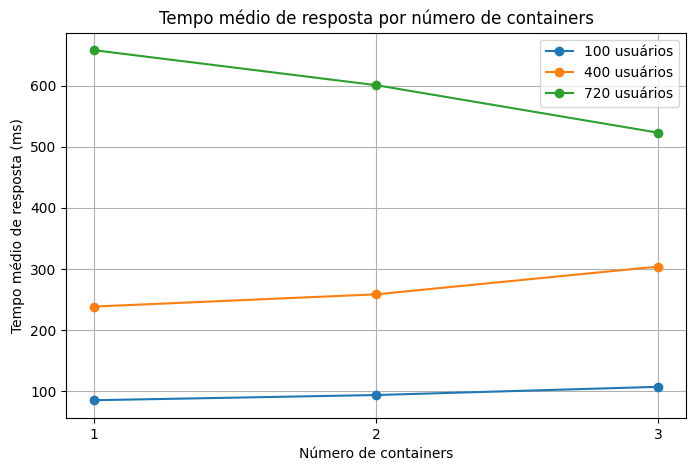

In [12]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["tempo_medio_resposta"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio de resposta por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

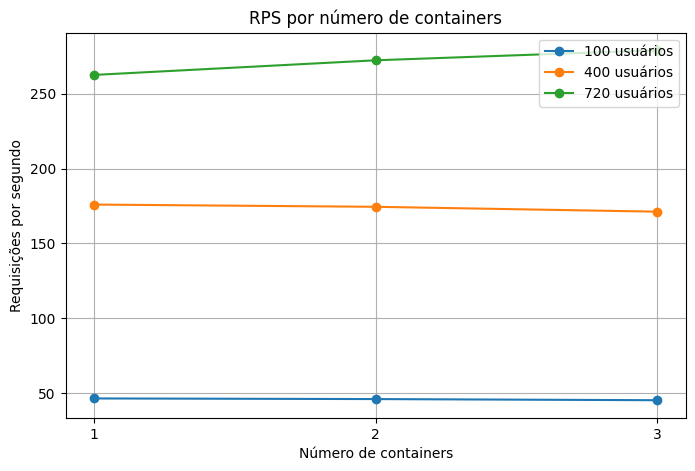

In [13]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["rps"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Requisições por segundo")
plt.title("RPS por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

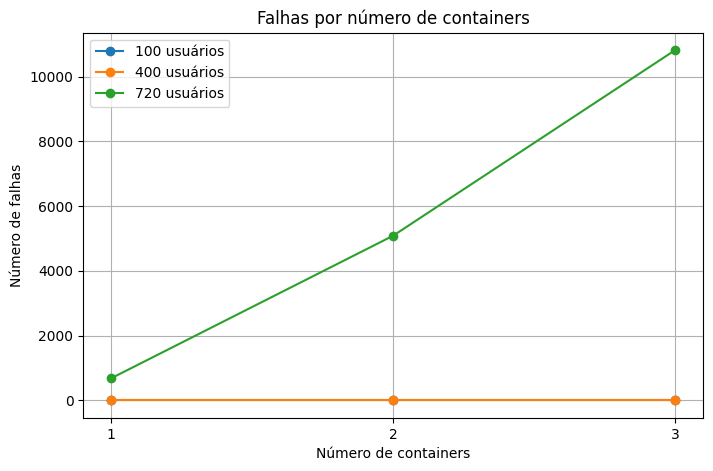

In [14]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["falhas"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Número de falhas")
plt.title("Falhas por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

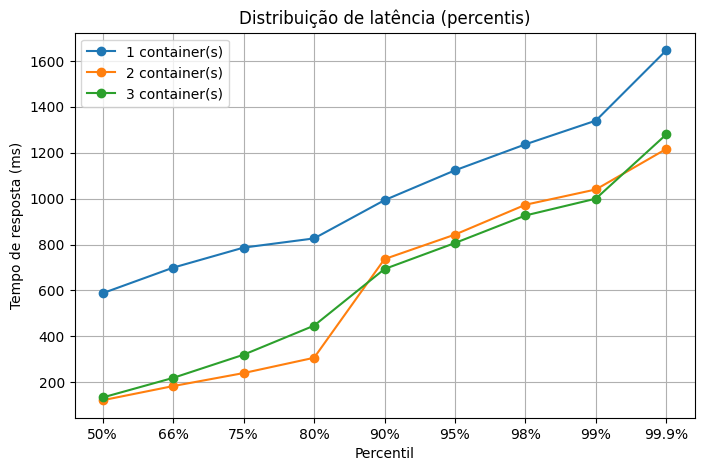

In [15]:
percentis = ["50%", "66%", "75%", "80%", "90%", "95%", "98%", "99%", "99.9%"]

plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    df_plot = []
    
    for usuarios in [100, 400, 800]:
        df = pd.read_csv(dados_path / f"{containers}container{'s' if containers > 1 else ''}_{usuarios}users.csv")
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        valores = [agg[p] for p in percentis]
        df_plot.append(valores)
    
    media = pd.DataFrame(df_plot).mean()
    plt.plot(percentis, media, marker="o", label=f"{containers} container(s)")

plt.xlabel("Percentil")
plt.ylabel("Tempo de resposta (ms)")
plt.title("Distribuição de latência (percentis)")
plt.legend()
plt.grid(True)
plt.show()

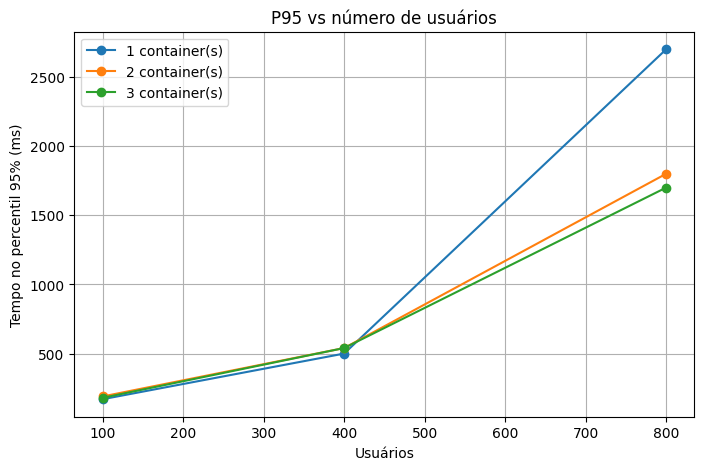

In [16]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = []
    
    for usuarios in [100, 400, 800]:
        df = pd.read_csv(dados_path / f"{containers}container{'s' if containers > 1 else ''}_{usuarios}users.csv")
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        dados.append(agg["95%"])
    
    plt.plot([100, 400, 800], dados, marker="o", label=f"{containers} container(s)")

plt.xlabel("Usuários")
plt.ylabel("Tempo no percentil 95% (ms)")
plt.title("P95 vs número de usuários")
plt.legend()
plt.grid(True)
plt.show()

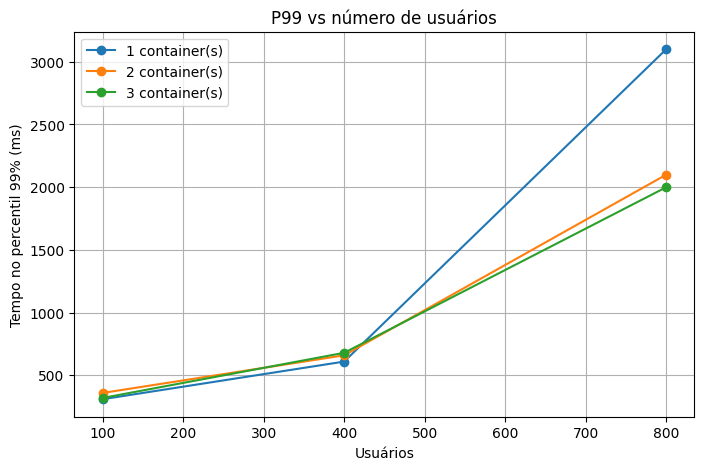

In [17]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = []
    
    for usuarios in [100, 400, 800]:
        df = pd.read_csv(dados_path / f"{containers}container{'s' if containers > 1 else ''}_{usuarios}users.csv")
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        dados.append(agg["99%"])
    
    plt.plot([100, 400, 800], dados, marker="o", label=f"{containers} container(s)")

plt.xlabel("Usuários")
plt.ylabel("Tempo no percentil 99% (ms)")
plt.title("P99 vs número de usuários")
plt.legend()
plt.grid(True)
plt.show()